# EEG Seizure Classification
### A machine learning approach to epilepsy detection
**Dataset:** Kaggle Epileptic Seizure Recognition  
**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
# Step 1 - Load the data
df = pd.read_csv('Epileptic Seizure Recognition.csv')

# Step 2 - Drop the text column 
df = df.drop(columns=['Unnamed'])

# Step 3 - Convert target to binary
df['y'] = df['y'].apply(lambda x: 1 if x == 1 else 0)

# Step 4 - Confirm everything looks clean
print("Shape:", df.shape)
print("Column types:\n", df.dtypes.value_counts())
print("Class distribution:\n", df['y'].value_counts())

Shape: (11500, 179)
Column types:
 int64    179
Name: count, dtype: int64
Class distribution:
 y
0    9200
1    2300
Name: count, dtype: int64


In [4]:
df.head ()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,0
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,0
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,0
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,0


In [5]:
df.shape

(11500, 179)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 179 entries, X1 to y
dtypes: int64(179)
memory usage: 15.7 MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,0.200000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,0.400017
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,0.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,0.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,0.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,0.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,1.000000


In [9]:
df.isnull().sum()

X1      0
X2      0
X3      0
X4      0
X5      0
       ..
X175    0
X176    0
X177    0
X178    0
y       0
Length: 179, dtype: int64

In [10]:
df['y'].value_counts()

y
0    9200
1    2300
Name: count, dtype: int64

In [11]:
df['y'] = df['y'].apply(lambda x: 1 if x == 1 else 0)

In [12]:
df['y'].value_counts()

y
0    9200
1    2300
Name: count, dtype: int64

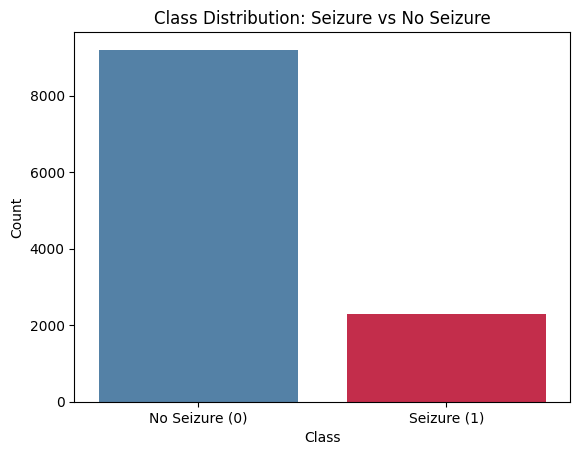

In [13]:
sns.countplot(x='y', data=df, hue='y', palette=['steelblue', 'crimson'], legend=False)
plt.title('Class Distribution: Seizure vs No Seizure')
plt.xticks([0, 1], ['No Seizure (0)', 'Seizure (1)'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

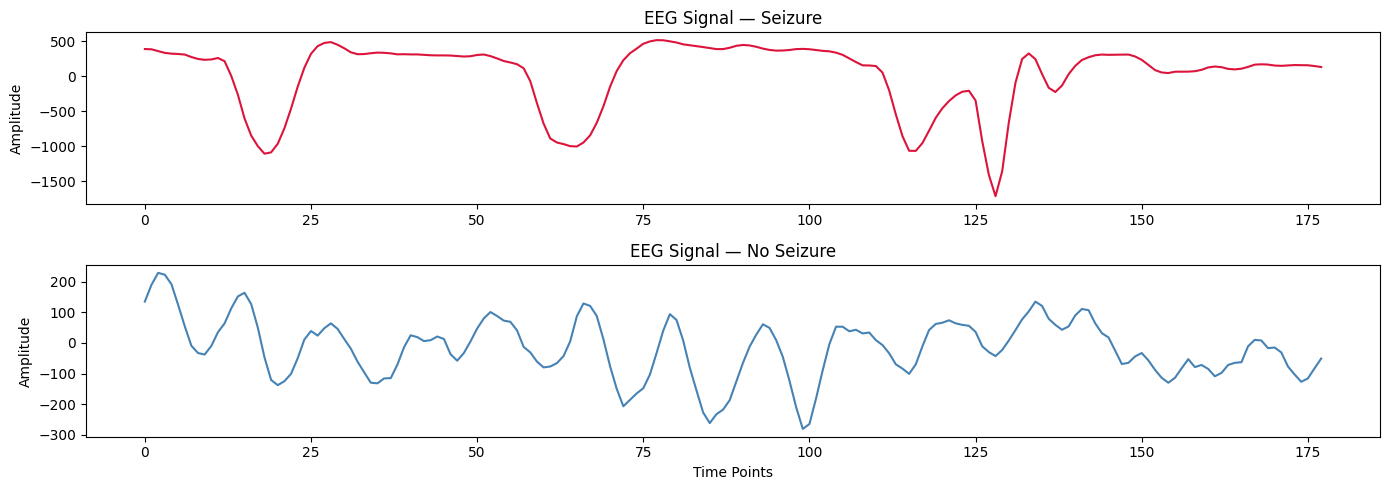

In [14]:
seizure_signal = df[df['y'] == 1].iloc[0, :-1].to_numpy().astype(float)
normal_signal = df[df['y'] == 0].iloc[0, :-1].to_numpy().astype(float)

plt.figure(figsize=(14, 5))

plt.subplot(2, 1, 1)
plt.plot(seizure_signal, color='crimson')
plt.title('EEG Signal — Seizure')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(normal_signal, color='steelblue')
plt.title('EEG Signal — No Seizure')
plt.ylabel('Amplitude')
plt.xlabel('Time Points')

plt.tight_layout()
plt.show()

In [15]:
df.dtypes.value_counts()

int64    179
Name: count, dtype: int64

In [16]:
df.select_dtypes(include='object').columns.tolist()

[]

In [17]:
df.groupby('y').describe().T

y                     0            1
X1   count  9200.000000  2300.000000
     mean     -8.992609   -21.936522
     std      70.455286   342.361939
     min    -566.000000 -1839.000000
     25%     -44.000000  -193.250000
...                 ...          ...
X178 min    -559.000000 -1829.000000
     25%     -45.000000  -189.000000
     50%      -8.000000   -23.000000
     75%      27.000000   157.250000
     max    1915.000000  1380.000000

[1424 rows x 2 columns]

In [18]:
X = df.drop(columns=['y'])
y = df['y']

In [19]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11500, 178)
Target shape: (11500,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (9200, 178)
Testing set size: (2300, 178)


In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
X.select_dtypes(include='object').columns.tolist()

[]

In [24]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9200, 178)
X_test shape: (2300, 178)
y_train shape: (9200,)
y_test shape: (2300,)


In [25]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("Logistic Regression training complete")

Logistic Regression training complete


In [26]:
y_pred_lr = lr.predict(X_test)
print("First 10 predictions:", y_pred_lr[:10])
print("First 10 actual values:", y_test.values[:10])

First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 actual values: [0 0 0 0 0 0 0 0 0 1]


In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest training complete")

Random Forest training complete


In [28]:
y_pred_rf = rf.predict(X_test)
print("First 10 predictions:", y_pred_rf[:10])
print("First 10 actual values:", y_test.values[:10])

First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 actual values: [0 0 0 0 0 0 0 0 0 1]


In [29]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"Random Forest Accuracy:       {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

Logistic Regression Accuracy: 0.8178 (81.78%)
Random Forest Accuracy:       0.9796 (97.96%)


In [30]:
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf,
      target_names=['No Seizure', 'Seizure']))

=== Random Forest ===
              precision    recall  f1-score   support

  No Seizure       0.99      0.99      0.99      1835
     Seizure       0.95      0.94      0.95       465

    accuracy                           0.98      2300
   macro avg       0.97      0.97      0.97      2300
weighted avg       0.98      0.98      0.98      2300



In [31]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr,
      target_names=['No Seizure', 'Seizure']))

=== Logistic Regression ===
              precision    recall  f1-score   support

  No Seizure       0.81      1.00      0.90      1835
     Seizure       0.98      0.10      0.18       465

    accuracy                           0.82      2300
   macro avg       0.90      0.55      0.54      2300
weighted avg       0.85      0.82      0.75      2300



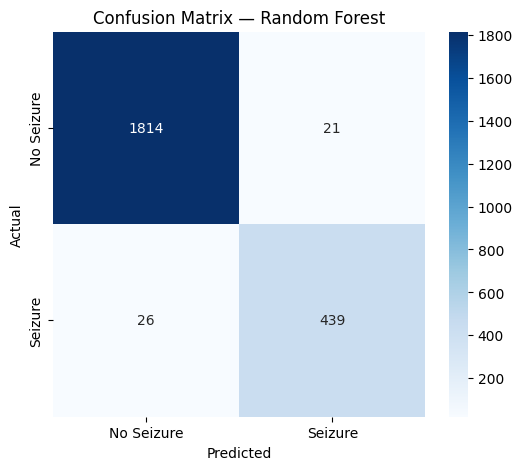

In [32]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Seizure', 'Seizure'],
            yticklabels=['No Seizure', 'Seizure'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

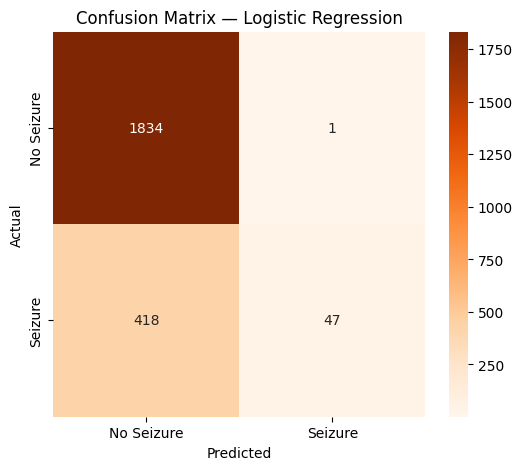

In [33]:
plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Seizure', 'Seizure'],
            yticklabels=['No Seizure', 'Seizure'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [34]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

print("Top 10 most important EEG time points:")
print(importances_sorted.head(10))

Top 10 most important EEG time points:
X17     0.020768
X16     0.017684
X168    0.015212
X111    0.015142
X169    0.014597
X113    0.014591
X92     0.014573
X25     0.014240
X37     0.014030
X127    0.013943
dtype: float64


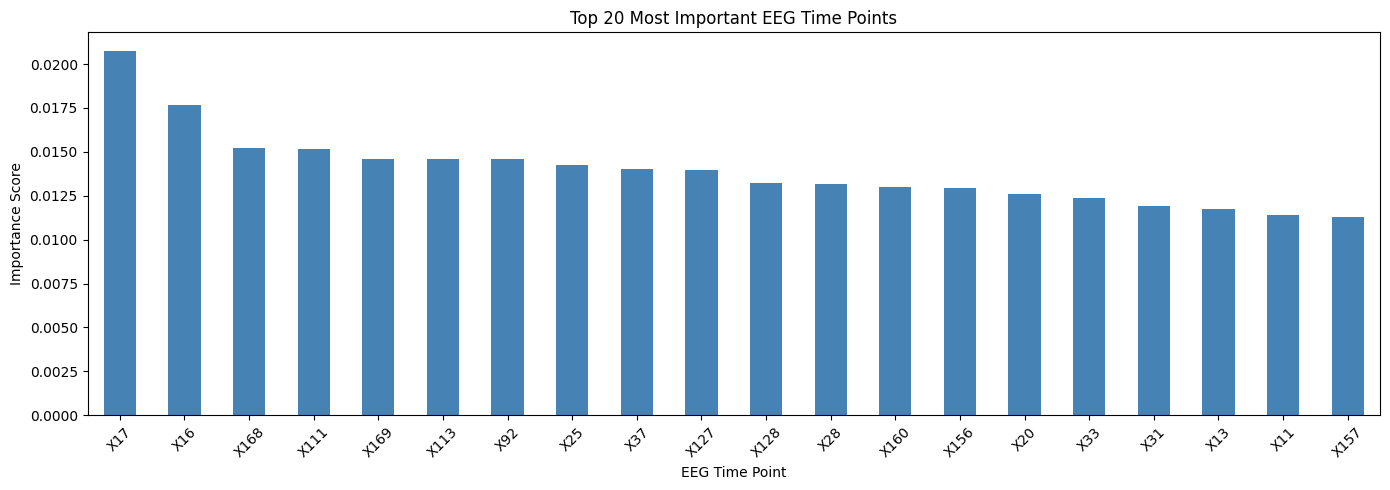

In [35]:
plt.figure(figsize=(14, 5))
importances_sorted[:20].plot(kind='bar', color='steelblue')
plt.title('Top 20 Most Important EEG Time Points')
plt.xlabel('EEG Time Point')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

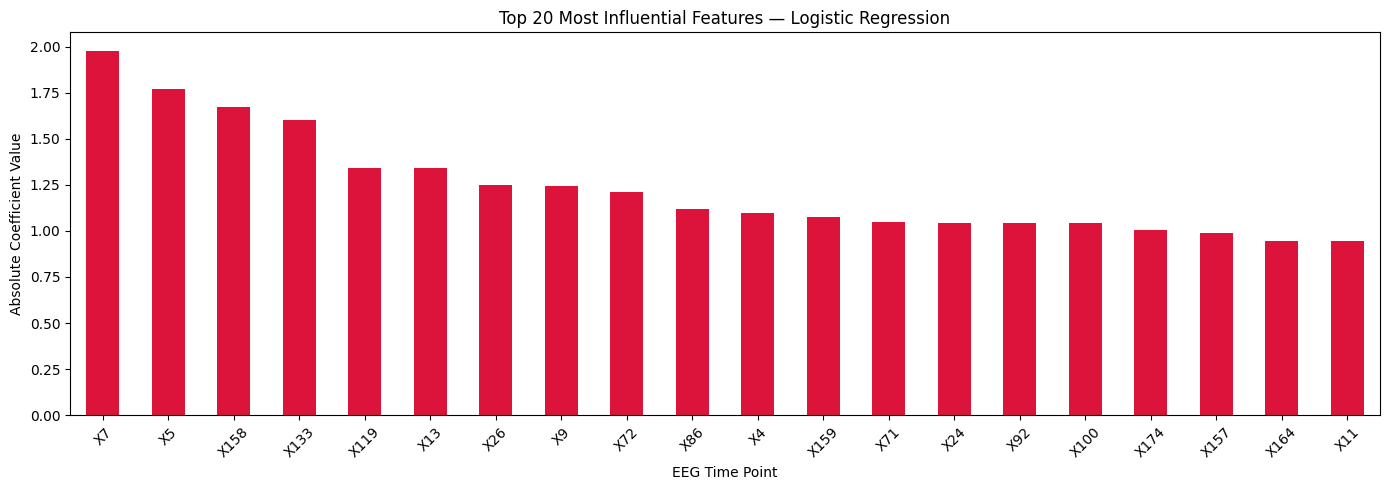

In [36]:
coefficients = pd.Series(lr.coef_[0], index=X.columns)
coefficients_sorted = coefficients.abs().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
coefficients_sorted[:20].plot(kind='bar', color='crimson')
plt.title('Top 20 Most Influential Features — Logistic Regression')
plt.xlabel('EEG Time Point')
plt.ylabel('Absolute Coefficient Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()